# 02_preprocessing

Goals:
- load CMAPSS FD001 train/test data
- compute RUL for training data
- inspect sensors
- select features
- normalize train and test consistently
- save processed outputs for modeling

In [40]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.data_loader import load_cmaps_file
from utils.preprocessing import add_rul, cap_rul, get_sensor_columns, scale_features

In [41]:
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [42]:
train_path = RAW_DIR / "train_FD001.txt"
test_path = RAW_DIR / "test_FD001.txt"
rul_path = RAW_DIR / "RUL_FD001.txt"

df_train = load_cmaps_file(train_path)
df_test = load_cmaps_file(test_path)

df_rul_test = pd.read_csv(rul_path, sep=r"\s+", header=None)
df_rul_test = df_rul_test.iloc[:, :1]
df_rul_test.columns = ["RUL"]

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("Test RUL shape:", df_rul_test.shape)

df_rul_test.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
Test RUL shape: (100, 1)


,RUL
0,112
1,98
2,69
3,82
4,91


In [43]:
df_train = add_rul(df_train)

df_train[["unit", "cycle", "RUL"]].head()

,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [44]:
df_train = cap_rul(df_train, max_rul=125)

df_train["RUL"].describe()

count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

In [45]:
sensor_cols = get_sensor_columns(df_train)
print(sensor_cols)
print("Number of sensors:", len(sensor_cols))

['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']
Number of sensors: 21


In [46]:
sensor_variance = df_train[sensor_cols].var().sort_values()
sensor_variance

s1     0.000000e+00
s10    0.000000e+00
s19    0.000000e+00
s18    0.000000e+00
s16    1.203765e-35
s5     2.840037e-29
s6     1.929279e-06
s15    1.406628e-03
s8     5.038938e-03
s13    5.172330e-03
s21    1.171825e-02
s20    3.266927e-02
s11    7.133568e-02
s2     2.500533e-01
s12    5.439850e-01
s7     7.833883e-01
s17    2.398667e+00
s3     3.759099e+01
s4     8.101089e+01
s14    3.639005e+02
s9     4.876536e+02
dtype: float64

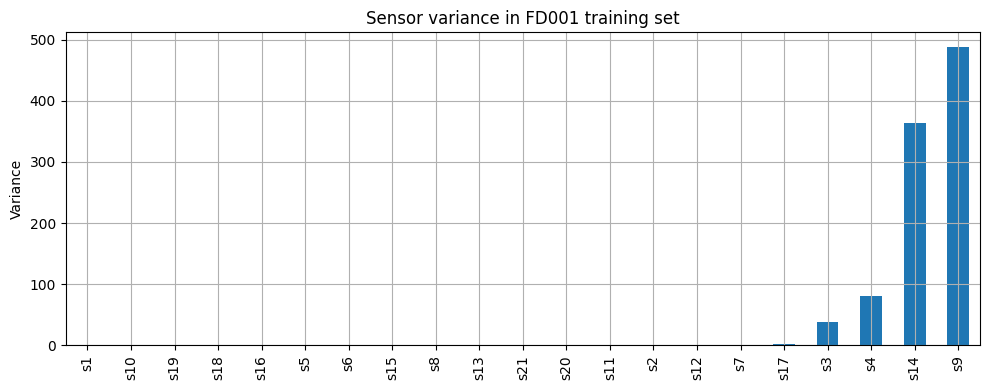

In [47]:
plt.figure(figsize=(10, 4))
sensor_variance.plot(kind="bar")
plt.title("Sensor variance in FD001 training set")
plt.ylabel("Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
low_variance_cols = sensor_variance[sensor_variance < 1e-8].index.tolist()
feature_cols = [col for col in sensor_cols if col not in low_variance_cols]

print("Dropped:", low_variance_cols)
print("Kept:", feature_cols)

Dropped: ['s1', 's10', 's19', 's18', 's16', 's5']
Kept: ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In [49]:
df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()

df_train_scaled, df_test_scaled, scaler = scale_features(
    df_train_scaled,
    df_test_scaled,
    feature_cols
)

In [50]:
display(df_train_scaled[feature_cols].head())
display(df_test_scaled[feature_cols].head())

,s2,s3,s4,s6,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
0,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662
1,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014
2,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375
3,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386
4,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502


,s2,s3,s4,s6,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
0,0.545181,0.310661,0.269413,1.0,0.652174,0.212121,0.127614,0.208333,0.646055,0.220588,0.132160,0.308965,0.333333,0.558140,0.661834
1,0.150602,0.379551,0.222316,1.0,0.805153,0.166667,0.146684,0.386905,0.739872,0.264706,0.204768,0.213159,0.416667,0.682171,0.686827
2,0.376506,0.346632,0.322248,1.0,0.685990,0.227273,0.158081,0.386905,0.699360,0.220588,0.155640,0.458638,0.416667,0.728682,0.721348
3,0.370482,0.285154,0.408001,1.0,0.679549,0.196970,0.105717,0.255952,0.573561,0.250000,0.170090,0.257022,0.250000,0.666667,0.662110
4,0.391566,0.352082,0.332039,1.0,0.694042,0.166667,0.102396,0.273810,0.737740,0.220588,0.152751,0.300885,0.166667,0.658915,0.716377


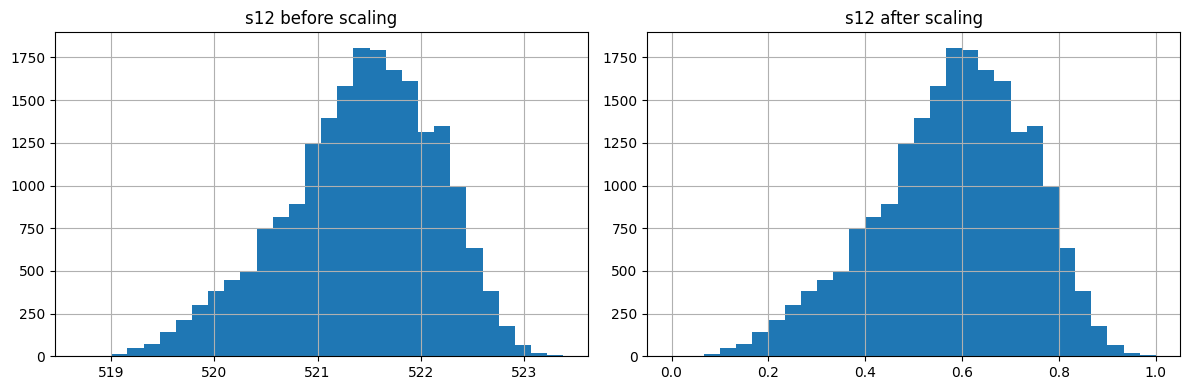

In [51]:
sensor = "s12"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train[sensor], bins=30)
axes[0].set_title(f"{sensor} before scaling")
axes[0].grid(True)

axes[1].hist(df_train_scaled[sensor], bins=30)
axes[1].set_title(f"{sensor} after scaling")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [52]:
df_train_scaled.to_csv(PROCESSED_DIR / "train_fd001_processed.csv", index=False)
df_test_scaled.to_csv(PROCESSED_DIR / "test_fd001_processed.csv", index=False)
df_rul_test.to_csv(PROCESSED_DIR / "rul_fd001_test.csv", index=False)

pd.Series(feature_cols).to_csv(PROCESSED_DIR / "fd001_feature_cols.csv", index=False, header=False)

print("Processed files saved.")

Processed files saved.
